## Dataset Exploration

In [1]:
from pathlib import Path

data_root = Path("..") / "dataset" / "datasetv2_TrainUclean"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}

dataset_info = {}

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
    class_counts = {}

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        image_count = sum(
            1
            for file_path in class_dir.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in image_extensions
        )

        class_counts[class_dir.name] = image_count

    dataset_info[split_dir.name] = class_counts

    print(f"\n{split_dir.name}:")
    print(f"Classes ({len(class_counts)}): {list(class_counts.keys())}")

    for class_name, image_count in class_counts.items():
        print(f"  {class_name}: {image_count} images")

    print(f"Total images: {sum(class_counts.values())}")


train:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 169 images
  autobus: 195 images
  kamyun: 200 images
  kamyunet: 188 images
  minibus: 180 images
  savari: 200 images
  taxi: 200 images
  vanet: 200 images
Total images: 1532

unclean:
Classes (9): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'neysan', 'savari', 'taxi', 'vanet']
  ambulance: 107 images
  autobus: 176 images
  kamyun: 196 images
  kamyunet: 171 images
  minibus: 135 images
  neysan: 200 images
  savari: 200 images
  taxi: 193 images
  vanet: 200 images
Total images: 1578


In [2]:
from pathlib import Path

import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Locate the raw dataset
# ---------------------------------------------------------

data_root = Path("..") / "dataset" / "datasetv2_TrainUclean"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}


# ---------------------------------------------------------
# 2. Inspect every image in every class of every split
# ---------------------------------------------------------

records = []

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):

        for file_path in sorted(class_dir.rglob("*")):

            # Ignore files that are not recognized as images
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in image_extensions:
                continue

            # Default values in case the image cannot be read
            width = None
            height = None
            dpi_x = None
            dpi_y = None
            image_format = None
            mode = None
            readable = False
            aspect_ratio = None
            error = None

            try:
                # Open the image
                with Image.open(file_path) as img:

                    # Basic image information
                    width, height = img.size
                    image_format = img.format
                    mode = img.mode

                    # DPI information
                    dpi = img.info.get("dpi")

                    if dpi is not None:
                        dpi_x, dpi_y = dpi

                    # Aspect ratio
                    if height != 0:
                        aspect_ratio = width / height

                    # Verify that the image data can actually be read
                    img.verify()

                    readable = True

            except Exception as e:
                error = str(e)

            # Store everything in one record
            records.append({
                "split": split_dir.name,
                "class": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path),
                "width": width,
                "height": height,
                "dpi_x": dpi_x,
                "dpi_y": dpi_y,
                "format": image_format,
                "mode": mode,
                "readable": readable,
                "aspect_ratio": aspect_ratio,
                "error": error,
            })


# ---------------------------------------------------------
# 3. Create one master DataFrame
# ---------------------------------------------------------

image_metadata = pd.DataFrame(records)


# ---------------------------------------------------------
# 4. Display basic information
# ---------------------------------------------------------

print(f"Total images inspected: {len(image_metadata)}")

print(
    f"Unreadable images: "
    f"{(~image_metadata['readable']).sum()}"
)

Total images inspected: 3110
Unreadable images: 0


## primary_manual_check for Class fix of mismatched photos

In [5]:
from vehicle_classifier.apply_corrections import run_corrections

stats = run_corrections(
    raw_dir="../dataset/datasetv2_TrainUclean",
    csv_path="../data/6- label_corrections_primary_manual_check_dataset_V2.csv",
    output_dir="../dataset/V2_cleaned_V1",
)

LABEL CORRECTION REPORT
Images scanned in raw dataset : 3110
  -> linked unchanged (no action found)   : 2855
  -> relabeled                            : 208  (of which no-op, same class/split: 0)
  -> excluded                             : 0
  -> conflicts (multiple actions, skipped): 0
  -> relabeled but renamed to avoid overwrite: 0

Total files created in cleaned dataset: 3063

CSV rows total       : 256
CSV rows never matched to a real image on disk: 1

--- CSV ROWS WITH NO MATCHING IMAGE (possible typos) ---
  - Line 258: split='', class='vanet', filename='209939482.jpg' never matched an image under '..\dataset\datasetv2_TrainUclean//vanet/209939482.jpg'.

--- ERRORS (image skipped, needs manual fix) ---
  - Line 3: unrecognized action 'exculde' for train/ambulance/201107960.jpg. Skipped — image was NOT linked.
  - Line 4: unrecognized action 'exculde' for train/ambulance/209441415.jpg. Skipped — image was NOT linked.
  - Line 5: unrecognized action 'exculde' for train/ambulance/

# neysan merging into vanet in unclean split

### manually done

# finding duplicate images dataset

In [6]:
from IPython.display import HTML, display
from vehicle_classifier import duplicate_detection as dd

THRESHOLD = 0.9

hashed = dd.compute_phashes(dataset_dir='../dataset/V2_cleaned_V1',hash_method = "phash" )
report = dd.build_duplicate_report(hashed, similarity_threshold=THRESHOLD)

print('='*20)
print('--- all similar pairs ---')
display(HTML(dd.table_to_html(report)))

dd.save_duplicate_report(report)
dd.save_label_corrections(report)

# dd.compare_images(
#     r"dataset\raw\train\autobus\216664450.jpg",
#     r"dataset\raw\train\autobus\216802875.jpg",
#     hash_method="phash",   # "ahash" | "phash" | "dhash" | "whash"
# )

Scanned: ..\dataset\V2_cleaned_V1  |  hash method: phash (16x16)  |  Hashed images: 3063  |  Failed to hash: 0
Compared 4689453 pairs  |  listed: similarity >= 0.90 (Hamming distance <= 25 of 256)  |  similar pairs found: 0
--- all similar pairs ---


similarity,cluster_num,same_class,class_a,class_b,same_split,split_a,split_b,filename_a,path_a,filename_b,path_b,auto_decision


Saved 0 rows to D:\BootCamp Sharif AI\Project 2 - Vehicle Classifier with traffic images\data\duplicate_pairs_report_1.csv
Saved 0 automatic exclusions to D:\BootCamp Sharif AI\Project 2 - Vehicle Classifier with traffic images\data\label_corrections_auto_duplicates.csv


WindowsPath('D:/BootCamp Sharif AI/Project 2 - Vehicle Classifier with traffic images/data/label_corrections_auto_duplicates.csv')

## unclean merge with train set

In [1]:
# manually done using windows copy feature easily

## finding too much similarities for preventing dataleakage on V2 of V2 dataset

Scanned: ..\dataset\V2_cleaned_V2  |  hash method: phash (16x16)  |  Hashed images: 3063  |  Failed to hash: 0
Compared 4689453 pairs  |  listed: similarity >= 0.75 (Hamming distance <= 64 of 256)  |  similar pairs found: 362
Clusters (size: count) -> none
Rows needing manual review: 362
--- all similar pairs ---


similarity,cluster_num,same_class,class_a,class_b,same_split,split_a,split_b,filename_a,path_a,filename_b,path_b,auto_decision
0.898,,True,minibus,minibus,True,train,train,206185314.jpg,..\dataset\V2_cleaned_V2\train\minibus\206185314.jpg,206187052.jpg,..\dataset\V2_cleaned_V2\train\minibus\206187052.jpg,needs review
0.891,,True,minibus,minibus,True,train,train,216573266.jpg,..\dataset\V2_cleaned_V2\train\minibus\216573266.jpg,218252019.jpg,..\dataset\V2_cleaned_V2\train\minibus\218252019.jpg,needs review
0.891,,True,minibus,minibus,True,train,train,218252019.jpg,..\dataset\V2_cleaned_V2\train\minibus\218252019.jpg,218982546.jpg,..\dataset\V2_cleaned_V2\train\minibus\218982546.jpg,needs review
0.867,,True,minibus,minibus,True,train,train,215859419.jpg,..\dataset\V2_cleaned_V2\train\minibus\215859419.jpg,218982546.jpg,..\dataset\V2_cleaned_V2\train\minibus\218982546.jpg,needs review
0.859,,True,autobus,autobus,True,train,train,218092463.jpg,..\dataset\V2_cleaned_V2\train\autobus\218092463.jpg,218952897.jpg,..\dataset\V2_cleaned_V2\train\autobus\218952897.jpg,needs review
0.859,,True,minibus,minibus,True,train,train,205930284.jpg,..\dataset\V2_cleaned_V2\train\minibus\205930284.jpg,206066058.jpg,..\dataset\V2_cleaned_V2\train\minibus\206066058.jpg,needs review
0.859,,True,minibus,minibus,True,train,train,216631528.jpg,..\dataset\V2_cleaned_V2\train\minibus\216631528.jpg,218106671.jpg,..\dataset\V2_cleaned_V2\train\minibus\218106671.jpg,needs review
0.852,,True,autobus,autobus,True,train,train,213748478.jpg,..\dataset\V2_cleaned_V2\train\autobus\213748478.jpg,216269810.jpg,..\dataset\V2_cleaned_V2\train\autobus\216269810.jpg,needs review
0.852,,True,autobus,autobus,True,train,train,215033304.jpg,..\dataset\V2_cleaned_V2\train\autobus\215033304.jpg,216623717.jpg,..\dataset\V2_cleaned_V2\train\autobus\216623717.jpg,needs review
0.852,,True,minibus,minibus,True,train,train,215836229.jpg,..\dataset\V2_cleaned_V2\train\minibus\215836229.jpg,215989638.jpg,..\dataset\V2_cleaned_V2\train\minibus\215989638.jpg,needs review

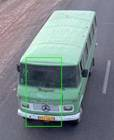
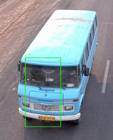
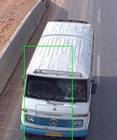
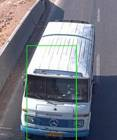
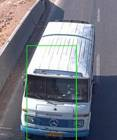
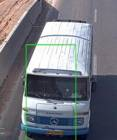
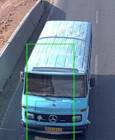
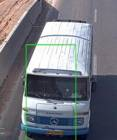
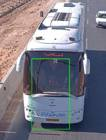
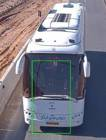
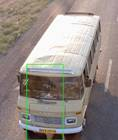
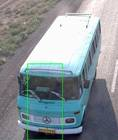
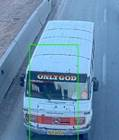
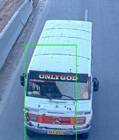
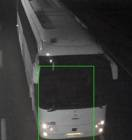
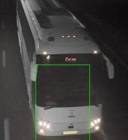
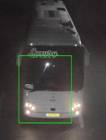
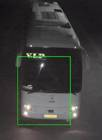
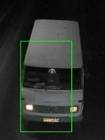
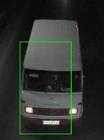
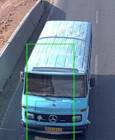
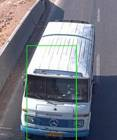
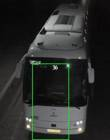
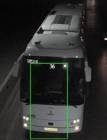
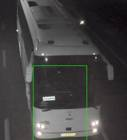
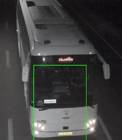
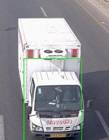
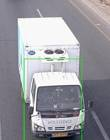
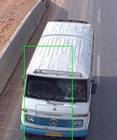
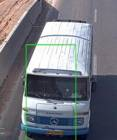
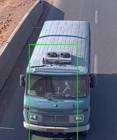
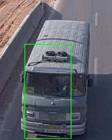
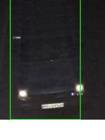
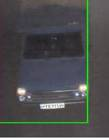
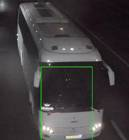
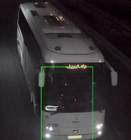
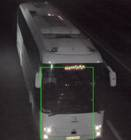
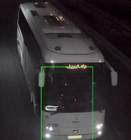
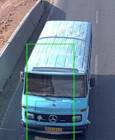
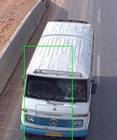
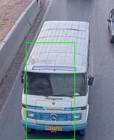
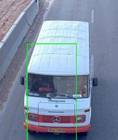
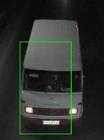
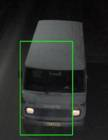
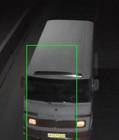
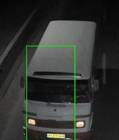
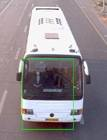
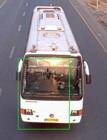
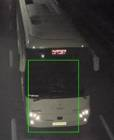
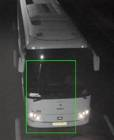
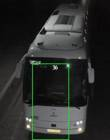
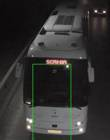
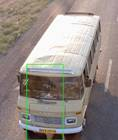
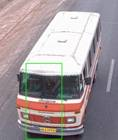
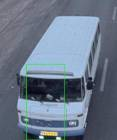
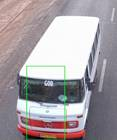
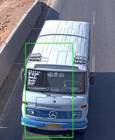
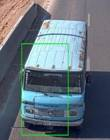
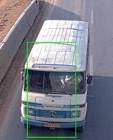
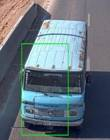
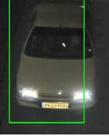
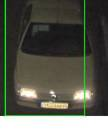
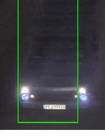
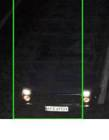
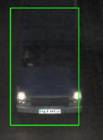
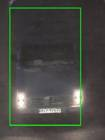
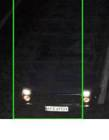
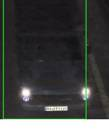
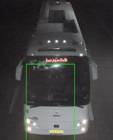
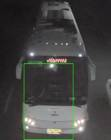
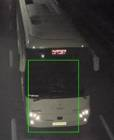
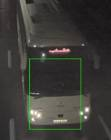
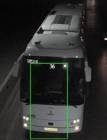
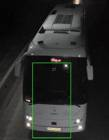
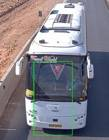
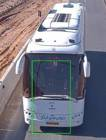
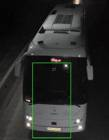
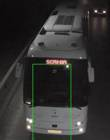
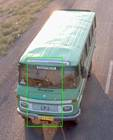
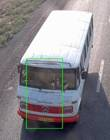
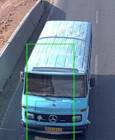
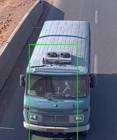
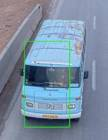
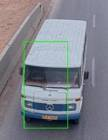
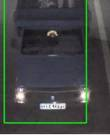
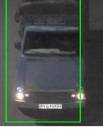
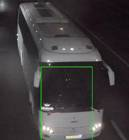
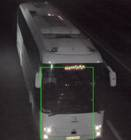
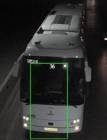
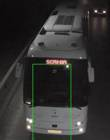
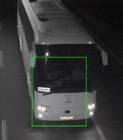
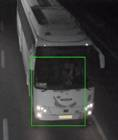
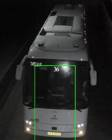
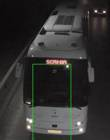
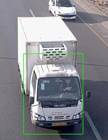
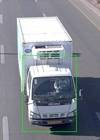
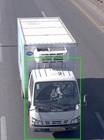
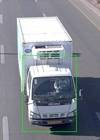
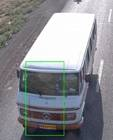
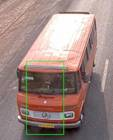
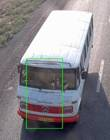
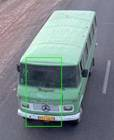
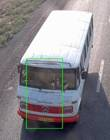
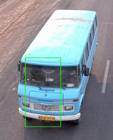
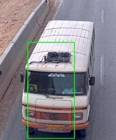
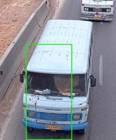
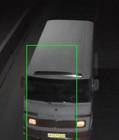
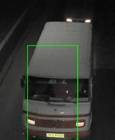
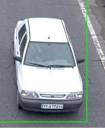
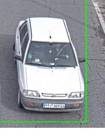
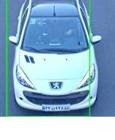
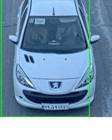
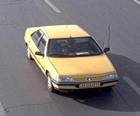
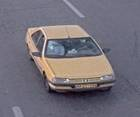
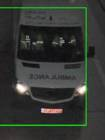
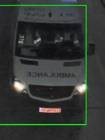
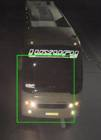
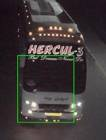
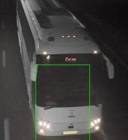
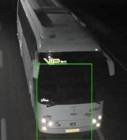
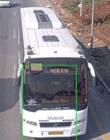
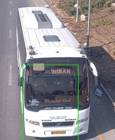
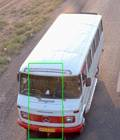
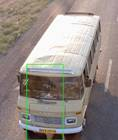
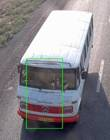
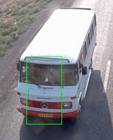
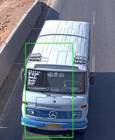
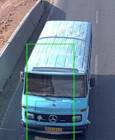
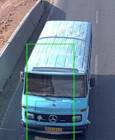
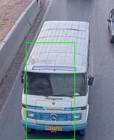
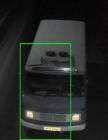
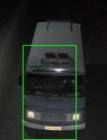
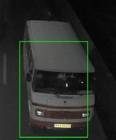
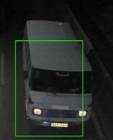
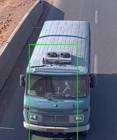
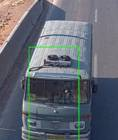
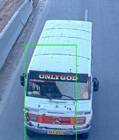
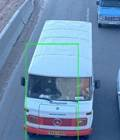
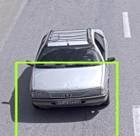
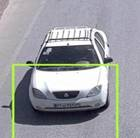
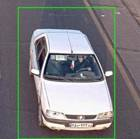
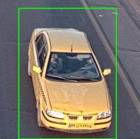
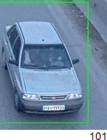
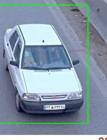
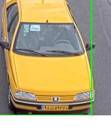
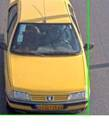
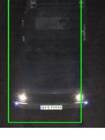
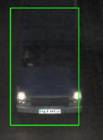
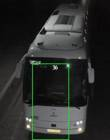
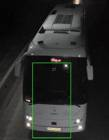
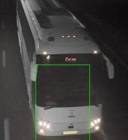
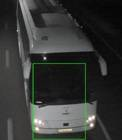
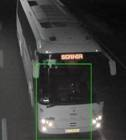
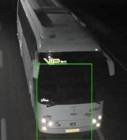
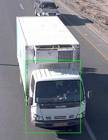
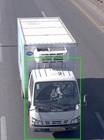
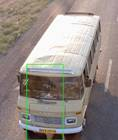
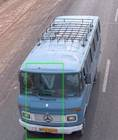
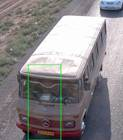
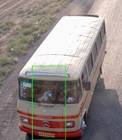
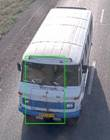
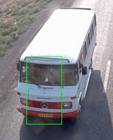
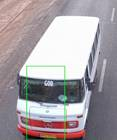
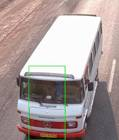
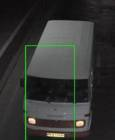
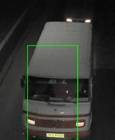
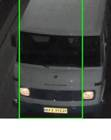
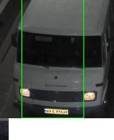
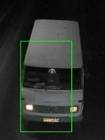
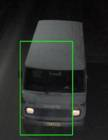
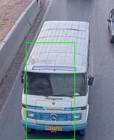
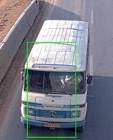
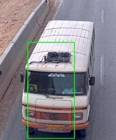
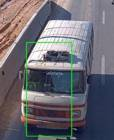
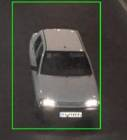
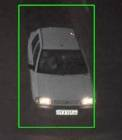
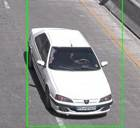
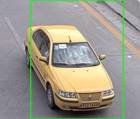
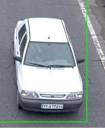
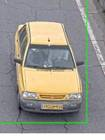
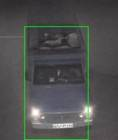
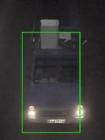
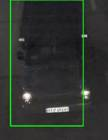
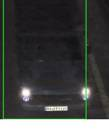
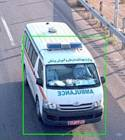
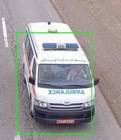
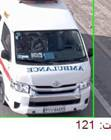
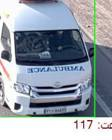
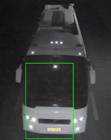
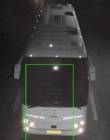
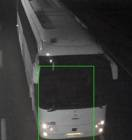
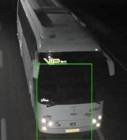
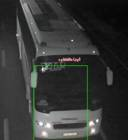
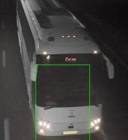
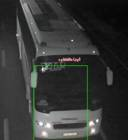
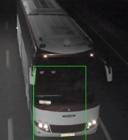
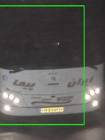
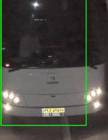
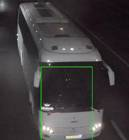
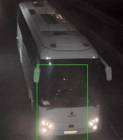
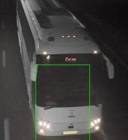
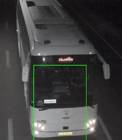
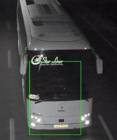
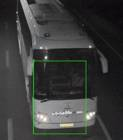
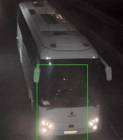
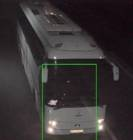
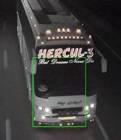
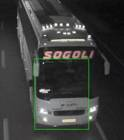
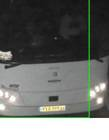
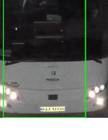
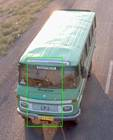
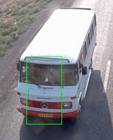
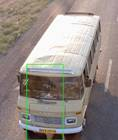
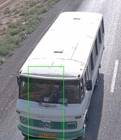
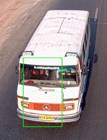
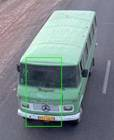
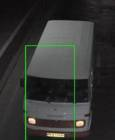
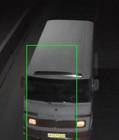
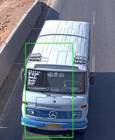
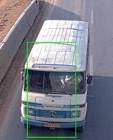
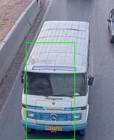
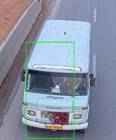
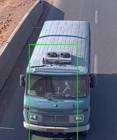
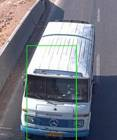
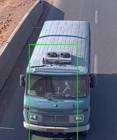
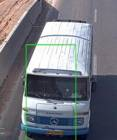
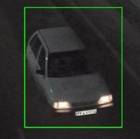
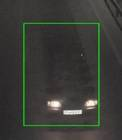
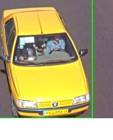
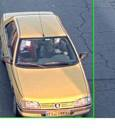
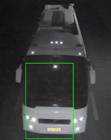
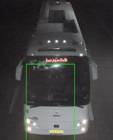
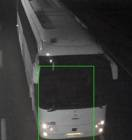
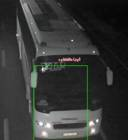
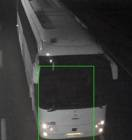
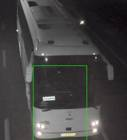
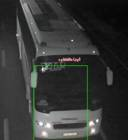
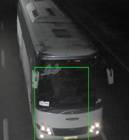
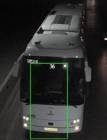
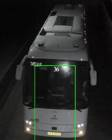
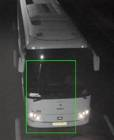
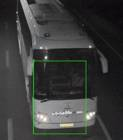
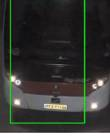
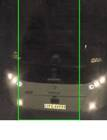
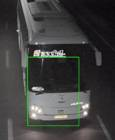
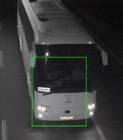
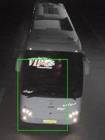
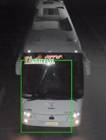
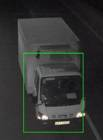
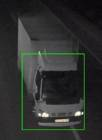
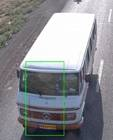
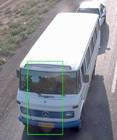
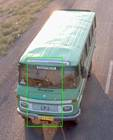
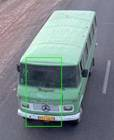
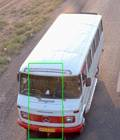
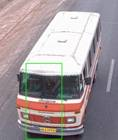
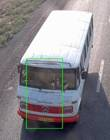
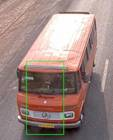
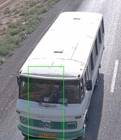
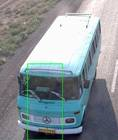
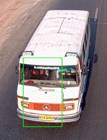
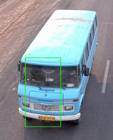
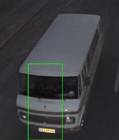
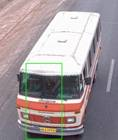
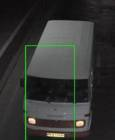
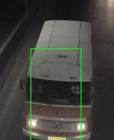
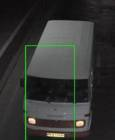
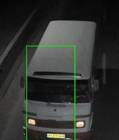
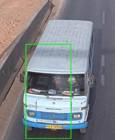
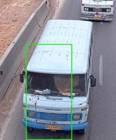
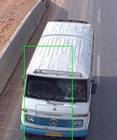
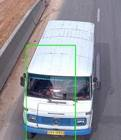
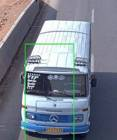
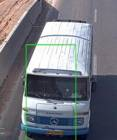
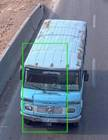
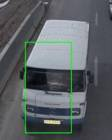
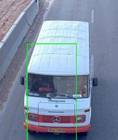
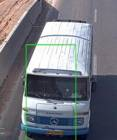
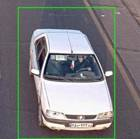
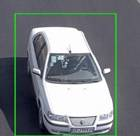
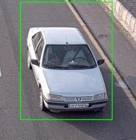
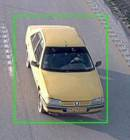
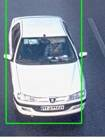
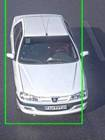
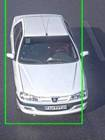
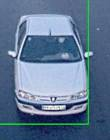
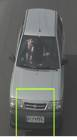
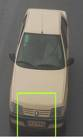
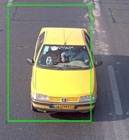
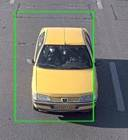
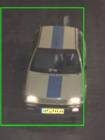
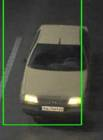
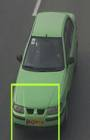
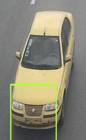
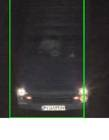
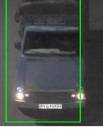
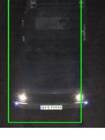
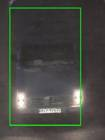
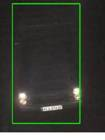
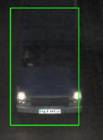
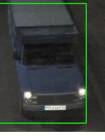
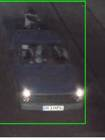
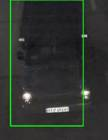
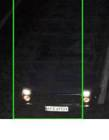
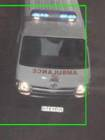
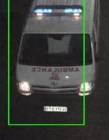
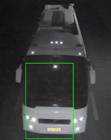
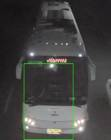
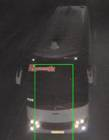
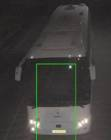
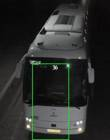
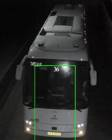
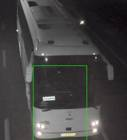
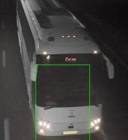
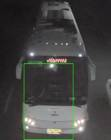
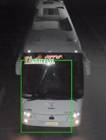
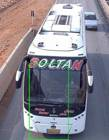
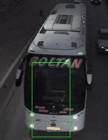
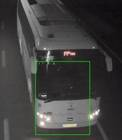
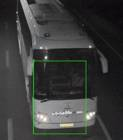
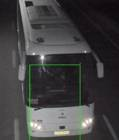
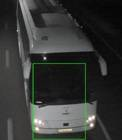
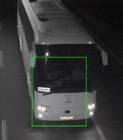
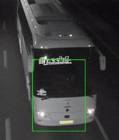
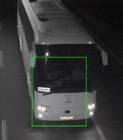
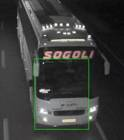
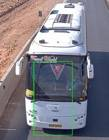
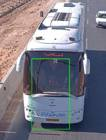
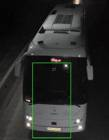
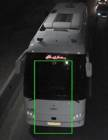
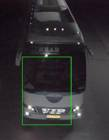
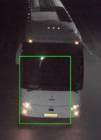
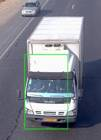
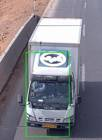
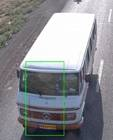
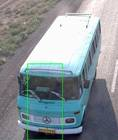
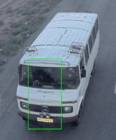
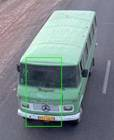
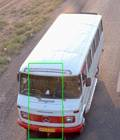
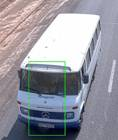
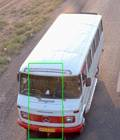
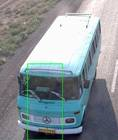
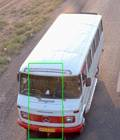
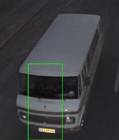
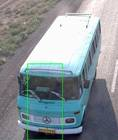
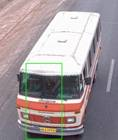
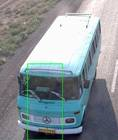
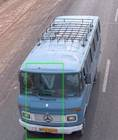
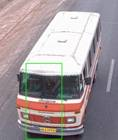
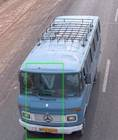
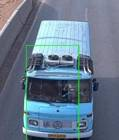
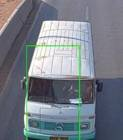
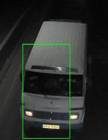
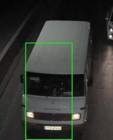
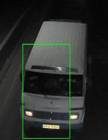
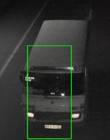
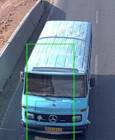
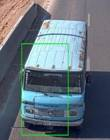
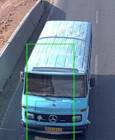
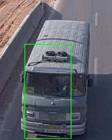
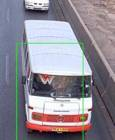
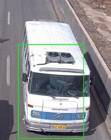
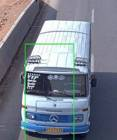
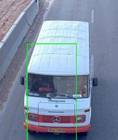
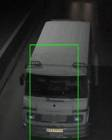
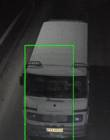
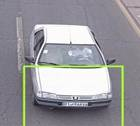
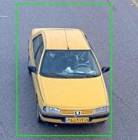
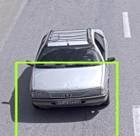
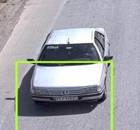
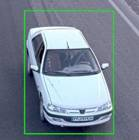
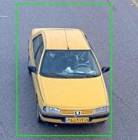
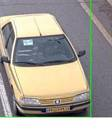
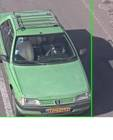
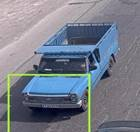
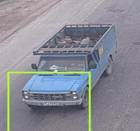
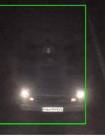
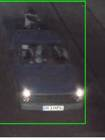
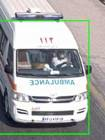
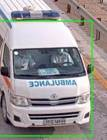
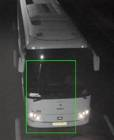
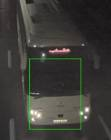
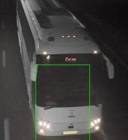
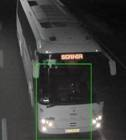
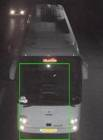
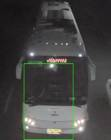
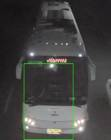
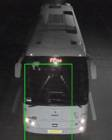
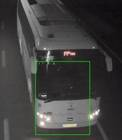
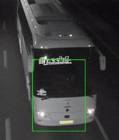
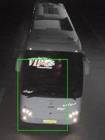
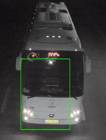
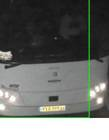
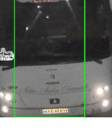
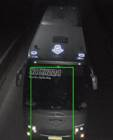
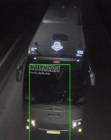
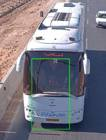
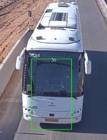
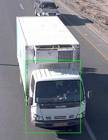
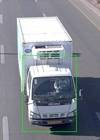
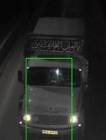
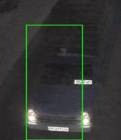
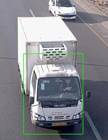
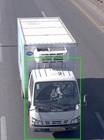
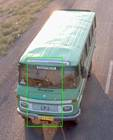
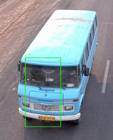
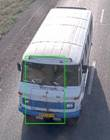
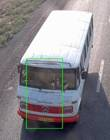
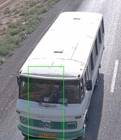
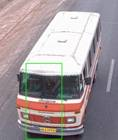
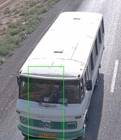
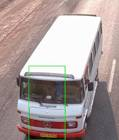
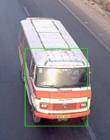
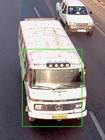
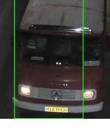
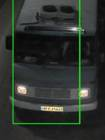
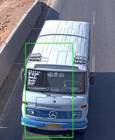
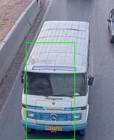
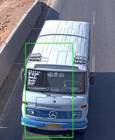
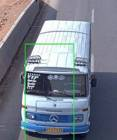
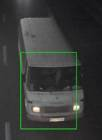
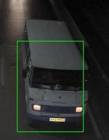
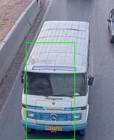
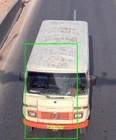
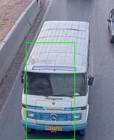
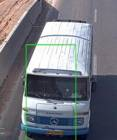
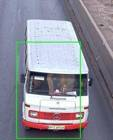
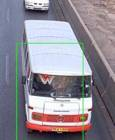
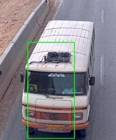
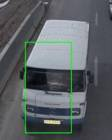
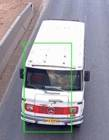
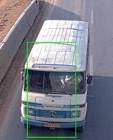
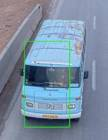
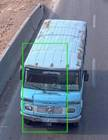
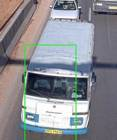
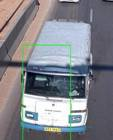
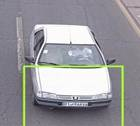
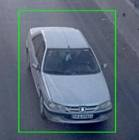
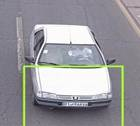
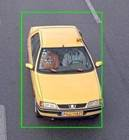
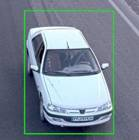
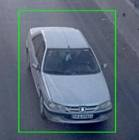
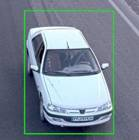
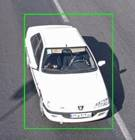
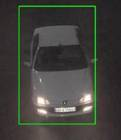
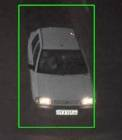
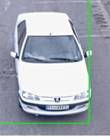
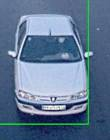
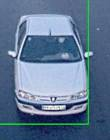
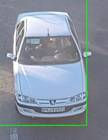
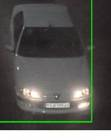
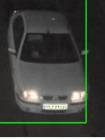
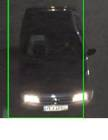
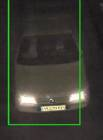
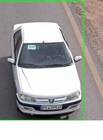
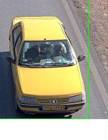
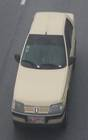
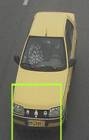
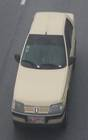
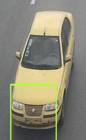
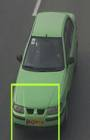
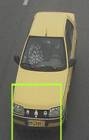
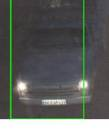
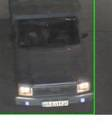
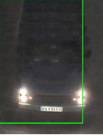
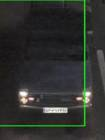
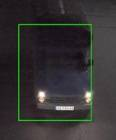
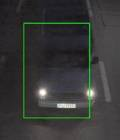
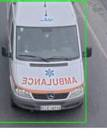
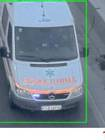
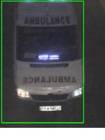
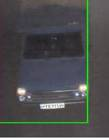
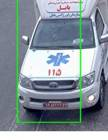
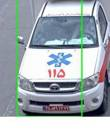
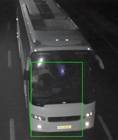
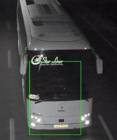
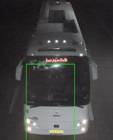
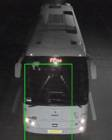
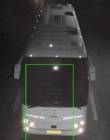
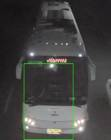
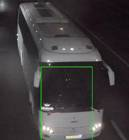
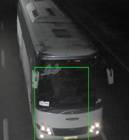
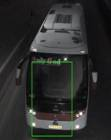
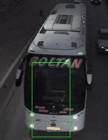
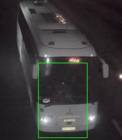
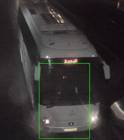
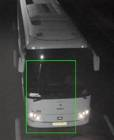
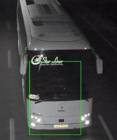
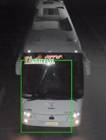
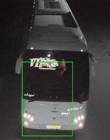
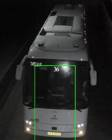
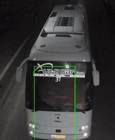
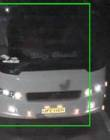
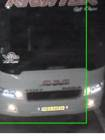
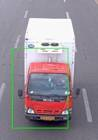
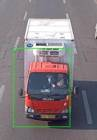
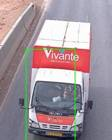
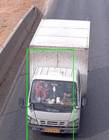
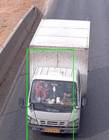
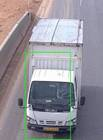
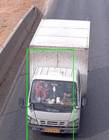
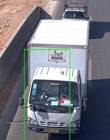
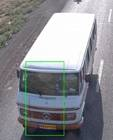
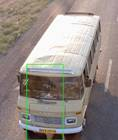
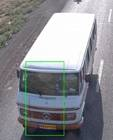
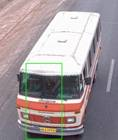
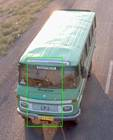
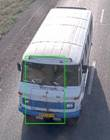
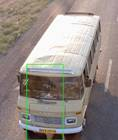
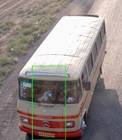
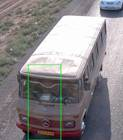
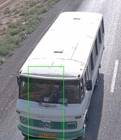
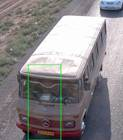
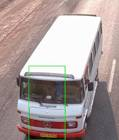
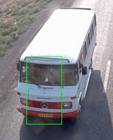
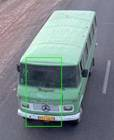
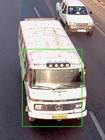
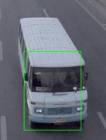
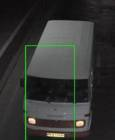
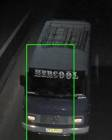
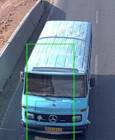
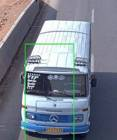
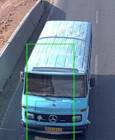
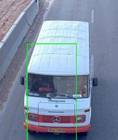
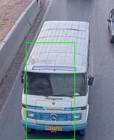
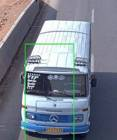
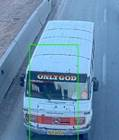
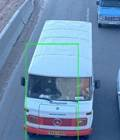
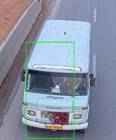
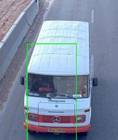
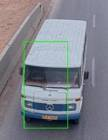
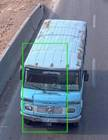
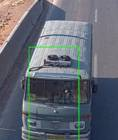
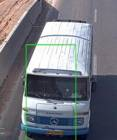
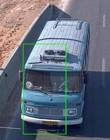
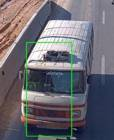
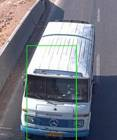
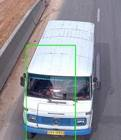
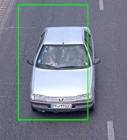
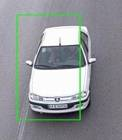
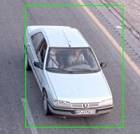
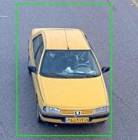
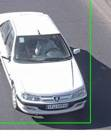
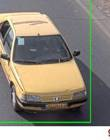
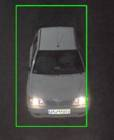
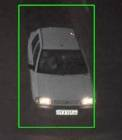
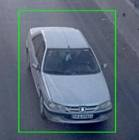
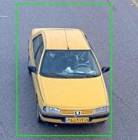
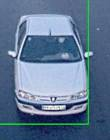
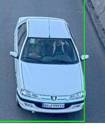
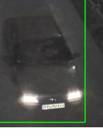
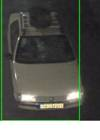
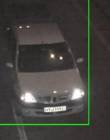
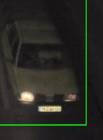
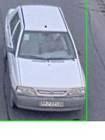
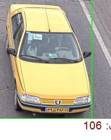
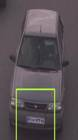
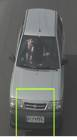
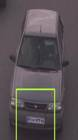
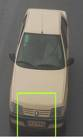
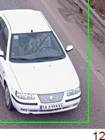
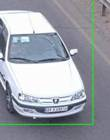
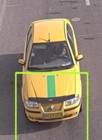
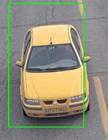
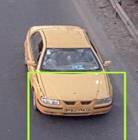
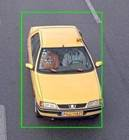
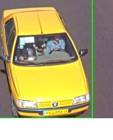
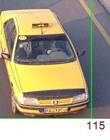
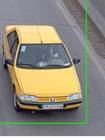
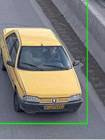
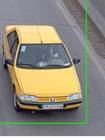
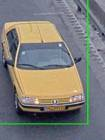
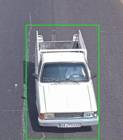
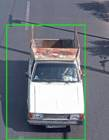
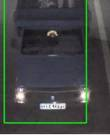
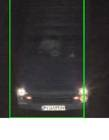
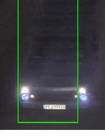
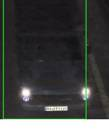
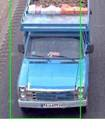
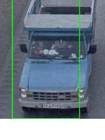
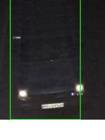
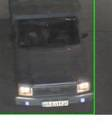
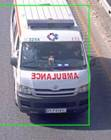
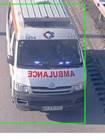
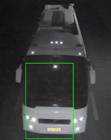
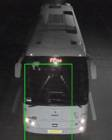
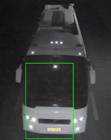
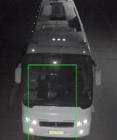
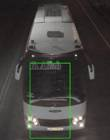
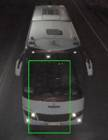
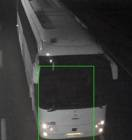
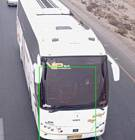
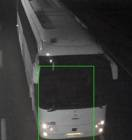
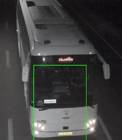
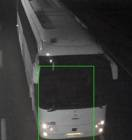
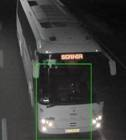
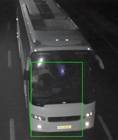
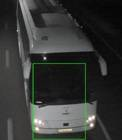
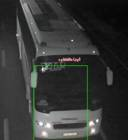
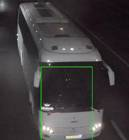
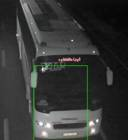
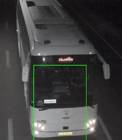
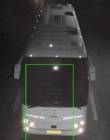
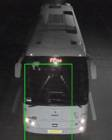
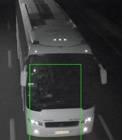
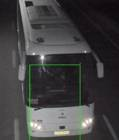
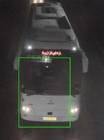
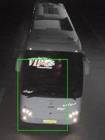
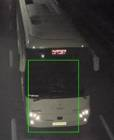
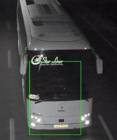
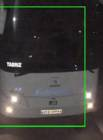
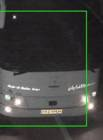
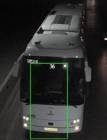
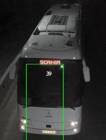
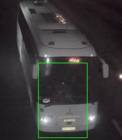
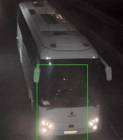
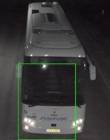
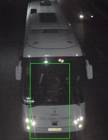
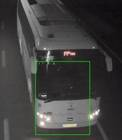
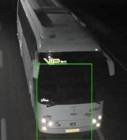
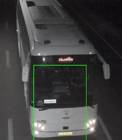
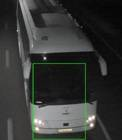
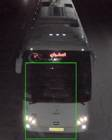
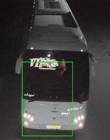
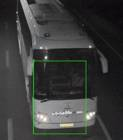
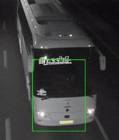
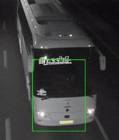
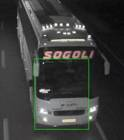
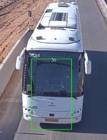
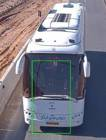
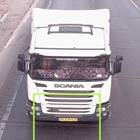
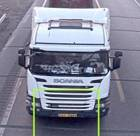
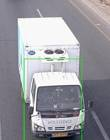
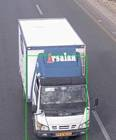
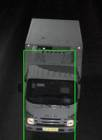
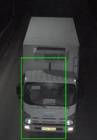
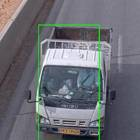
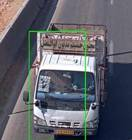
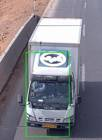
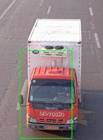
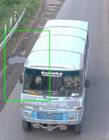
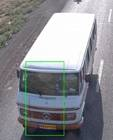
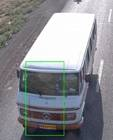
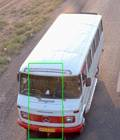
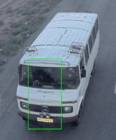
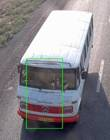
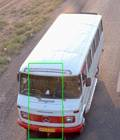
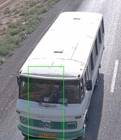
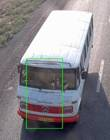
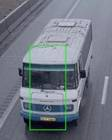
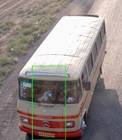
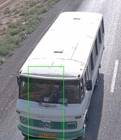
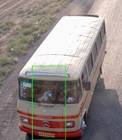
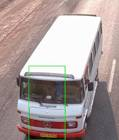
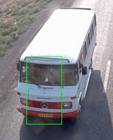
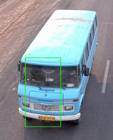
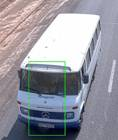
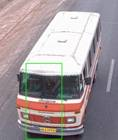
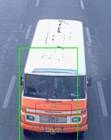
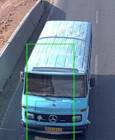
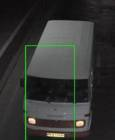
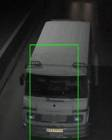
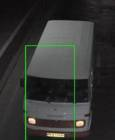
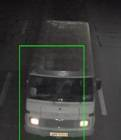
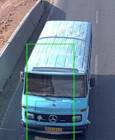
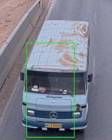
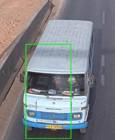
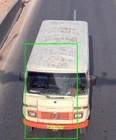
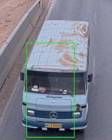
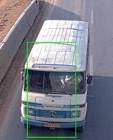
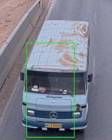
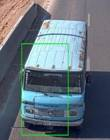
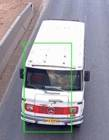
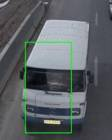
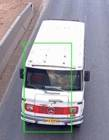
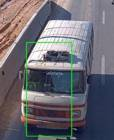
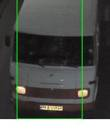
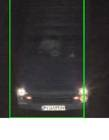
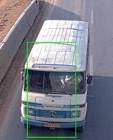
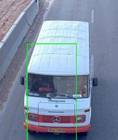
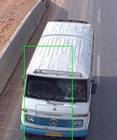
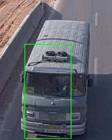
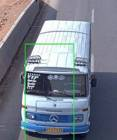
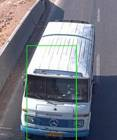
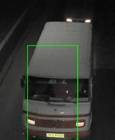
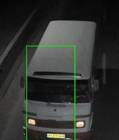
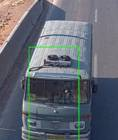
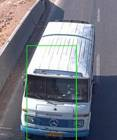
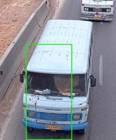
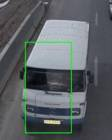
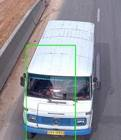
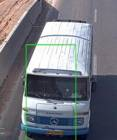
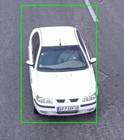
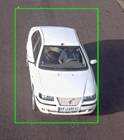
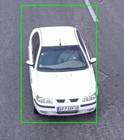
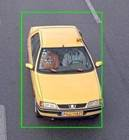
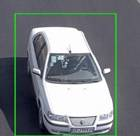
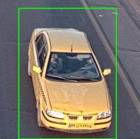
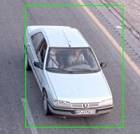
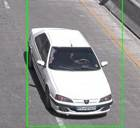
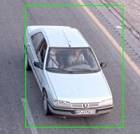
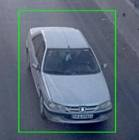
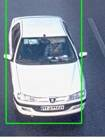
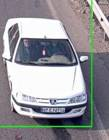
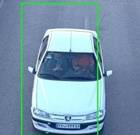
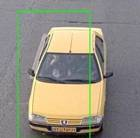
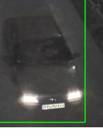
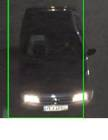
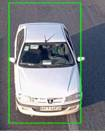
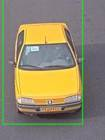
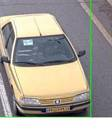
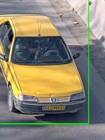
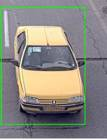
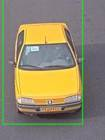
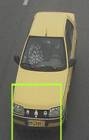
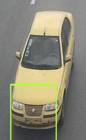
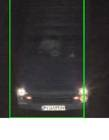
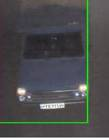
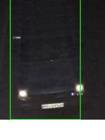
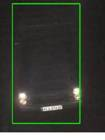
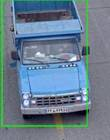
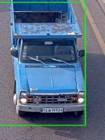
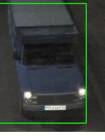
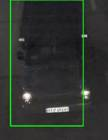

In [2]:
from IPython.display import HTML, display
from vehicle_classifier import duplicate_detection as dd

THRESHOLD = 0.75

hashed = dd.compute_phashes(dataset_dir='../dataset/V2_cleaned_V2',hash_method = "phash" )
report = dd.build_duplicate_report(hashed, similarity_threshold=THRESHOLD)

print('='*20)
print('--- all similar pairs ---')
display(HTML(dd.table_to_html(report)))

# dd.save_duplicate_report(report)
# dd.save_label_corrections(report)

# dd.compare_images(
#     r"dataset\raw\train\autobus\216664450.jpg",
#     r"dataset\raw\train\autobus\216802875.jpg",
#     hash_method="phash",   # "ahash" | "phash" | "dhash" | "whash"
# )

In [4]:
from pathlib import Path

data_root = Path("..") / "dataset" / "V2_cleaned_V1"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}

dataset_info = {}

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
    class_counts = {}

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        image_count = sum(
            1
            for file_path in class_dir.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in image_extensions
        )

        class_counts[class_dir.name] = image_count

    dataset_info[split_dir.name] = class_counts

    print(f"\n{split_dir.name}:")
    print(f"Classes ({len(class_counts)}): {list(class_counts.keys())}")

    for class_name, image_count in class_counts.items():
        print(f"  {class_name}: {image_count} images")

    print(f"Total images: {sum(class_counts.values())}")


train:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 164 images
  autobus: 195 images
  kamyun: 93 images
  kamyunet: 293 images
  minibus: 178 images
  savari: 199 images
  taxi: 197 images
  vanet: 199 images
Total images: 1518

unclean:
Classes (9): ['ambulance', 'autobus', 'kamyun', 'kamyun2', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 100 images
  autobus: 176 images
  kamyun: 82 images
  kamyun2: 96 images
  kamyunet: 170 images
  minibus: 132 images
  savari: 203 images
  taxi: 187 images
  vanet: 399 images
Total images: 1545
